# Advanced EDA and Feature Selection

This notebook reviews the customer-level feature table with business-oriented visuals, then selects a simple first-baseline feature set for clustering. It does not run clustering, fit models, or create association rules.

## Imports and Data Loading

Use the interpretable feature table for EDA visuals and the preprocessed model table for feature selection.

In [21]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 14

FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY = "#2F6B9A"
SECONDARY = "#4C956C"
ACCENT = "#D9822B"
MUTED = "#7A869A"


def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


def clean_label(value):
    return value.replace("share_", "").replace("_", " ").title()

In [22]:
customer_features = pd.read_csv("../data/processed/customer_features.csv")
customer_features_model = pd.read_csv("../data/processed/customer_features_model.csv")

print(f"customer_features shape: {customer_features.shape}")
print(f"customer_features_model shape: {customer_features_model.shape}")

customer_features shape: (33038, 37)
customer_features_model shape: (33038, 40)


In [23]:
customer_features.head()

,customer_id,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,year_first_transaction,percentage_of_products_bought_promotion,typical_hour,...,share_petfood,degree_level,basket_count,avg_basket_size,max_basket_size,min_basket_size,total_items_bought_in_baskets,distinct_products_in_baskets,avg_distinct_products_per_basket,most_frequent_product
0,3,female,1.0,1.0,1.0,3.0,189.0,2020.0,0.631599,NaN,...,0.020656,Bsc,2,10.5,11,10,21,21,10.5,asparagus
1,4,female,1.0,0.0,0.0,2.0,130.0,2013.0,0.149890,NaN,...,0.032867,Bsc,2,12.0,12,12,24,20,12.0,airpods
2,5,male,0.0,0.0,NaN,2.0,81.0,2005.0,0.069126,11.0,...,0.014277,Msc,1,8.0,8,8,8,8,8.0,bramble
3,7,male,0.0,0.0,2.0,1.0,92.0,2021.0,0.253609,18.0,...,0.012306,Unknown,1,4.0,4,4,4,4,4.0,cream
4,8,male,0.0,0.0,3.0,1.0,6.0,2021.0,0.186569,17.0,...,0.017095,Unknown,0,0.0,0,0,0,0,0.0,No Basket


## Customer Value

Review total customer value before looking at customer profiles. Large differences in total lifetime spend can strongly influence segmentation.

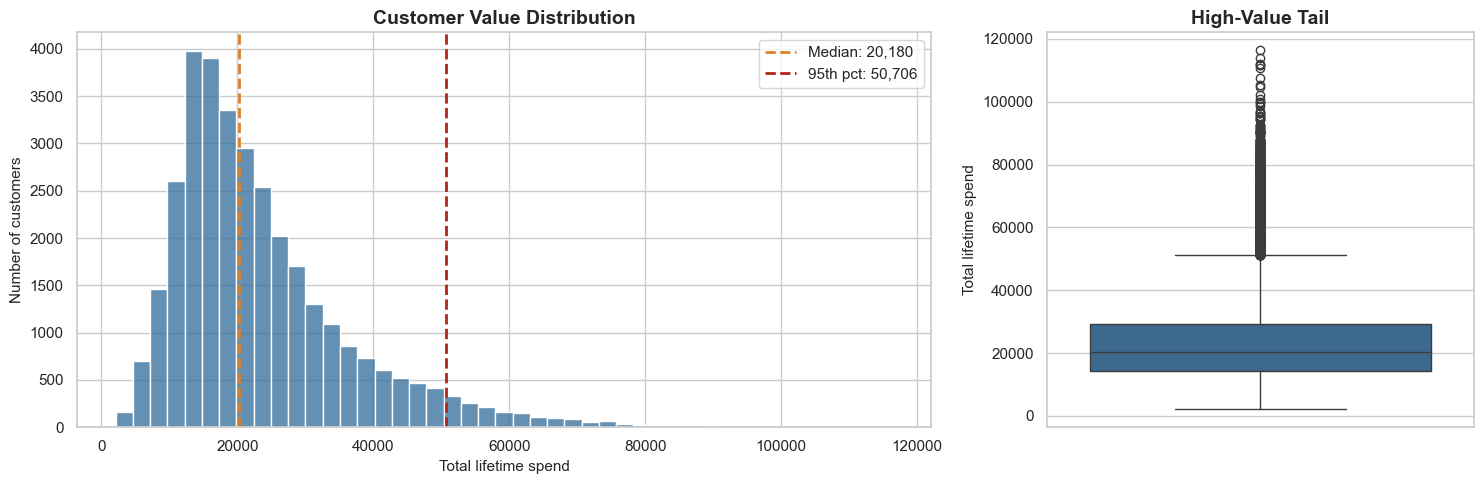

In [24]:
spend_median = customer_features["total_lifetime_spend"].median()
spend_p95 = customer_features["total_lifetime_spend"].quantile(0.95)
spend_p99 = customer_features["total_lifetime_spend"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2, 1]})

sns.histplot(customer_features["total_lifetime_spend"], bins=45, color=PRIMARY, ax=axes[0])
axes[0].axvline(spend_median, color=ACCENT, linestyle="--", linewidth=2, label=f"Median: {spend_median:,.0f}")
axes[0].axvline(spend_p95, color="#B42318", linestyle="--", linewidth=2, label=f"95th pct: {spend_p95:,.0f}")
axes[0].set_title("Customer Value Distribution")
axes[0].set_xlabel("Total lifetime spend")
axes[0].set_ylabel("Number of customers")
axes[0].legend(frameon=True)

sns.boxplot(data=customer_features, y="total_lifetime_spend", color=PRIMARY, ax=axes[1])
axes[1].set_title("High-Value Tail")
axes[1].set_ylabel("Total lifetime spend")
axes[1].set_xlabel("")

save_figure("customer_value_distribution.png")

In [25]:
spend_quantiles = customer_features["total_lifetime_spend"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_frame(name="total_lifetime_spend")
spend_quantiles

,total_lifetime_spend
0.50,20179.50
0.75,29093.75
0.90,41771.50
0.95,50705.90
0.99,69415.04


The spend distribution has a clear high-value tail: the median customer is far below the top percentiles. Spend should remain in the baseline, but scaling is essential so high-value customers do not dominate only by magnitude.

## Demographics and Lifecycle

Inspect age and tenure to see whether lifecycle differences may contribute to customer segments.

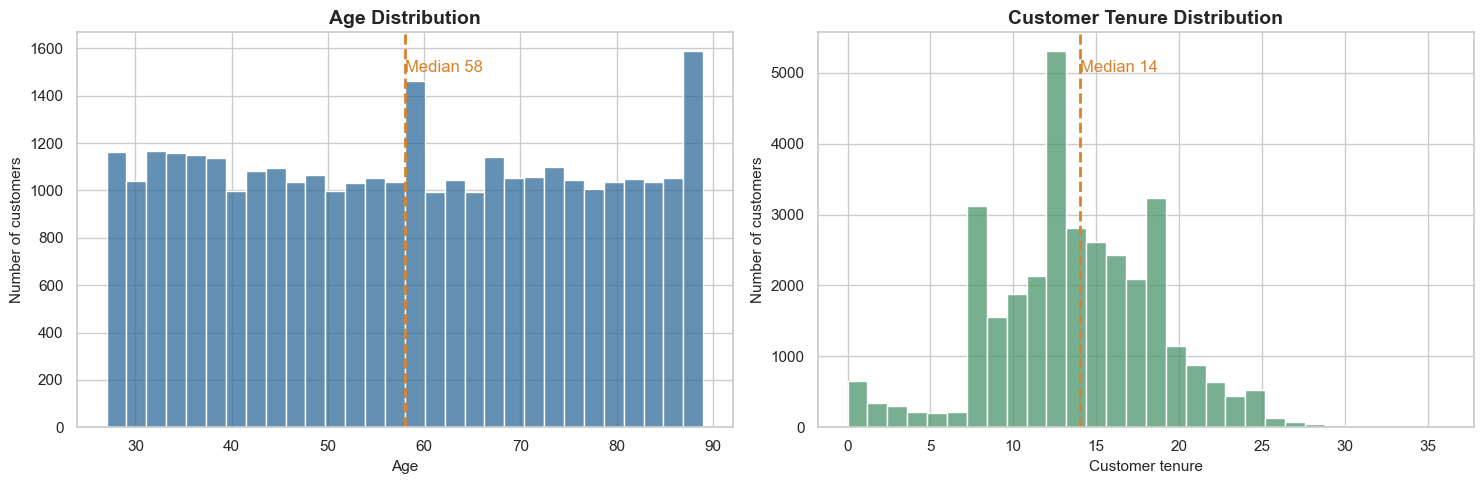

In [26]:
age_median = customer_features["age"].median()
tenure_median = customer_features["customer_tenure"].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(customer_features["age"], bins=30, color=PRIMARY, ax=axes[0])
axes[0].axvline(age_median, color=ACCENT, linestyle="--", linewidth=2)
axes[0].text(age_median, axes[0].get_ylim()[1] * 0.9, f"Median {age_median:.0f}", color=ACCENT, ha="left")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of customers")

sns.histplot(customer_features["customer_tenure"], bins=30, color=SECONDARY, ax=axes[1])
axes[1].axvline(tenure_median, color=ACCENT, linestyle="--", linewidth=2)
axes[1].text(tenure_median, axes[1].get_ylim()[1] * 0.9, f"Median {tenure_median:.0f}", color=ACCENT, ha="left")
axes[1].set_title("Customer Tenure Distribution")
axes[1].set_xlabel("Customer tenure")
axes[1].set_ylabel("Number of customers")

save_figure("demographics_lifecycle_distributions.png")

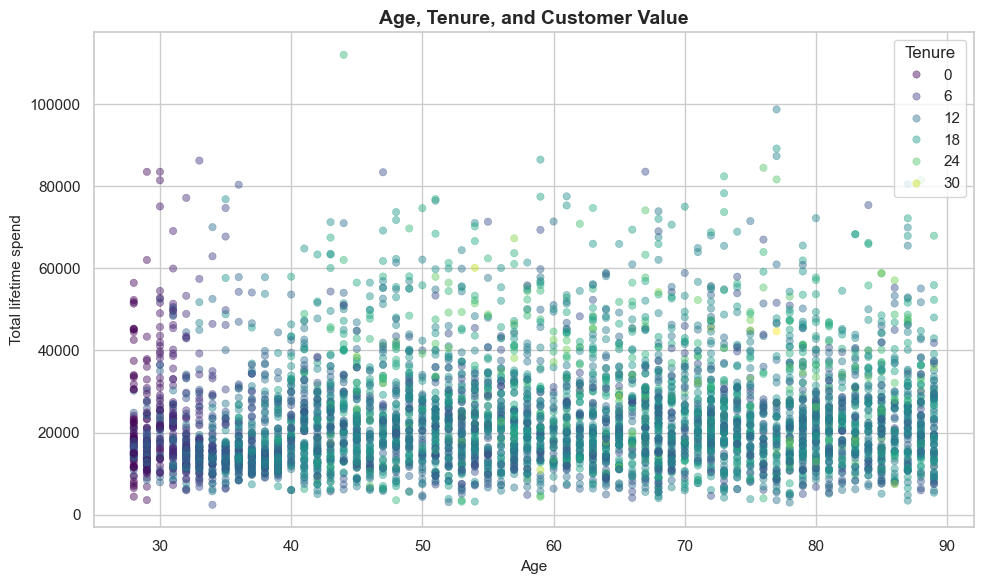

In [27]:
plot_sample = customer_features.sample(n=min(5000, len(customer_features)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x="age",
    y="total_lifetime_spend",
    hue="customer_tenure",
    palette="viridis",
    alpha=0.45,
    s=28,
    edgecolor=None,
    ax=ax,
)
ax.set_title("Age, Tenure, and Customer Value")
ax.set_xlabel("Age")
ax.set_ylabel("Total lifetime spend")
ax.legend(title="Tenure", loc="upper right", frameon=True)

save_figure("lifecycle_value_scatter.png")

Age and tenure both show broad variation, but the scatter does not point to a single simple age-spend rule. These lifecycle fields are useful context for segmentation when combined with value, preferences, and behaviour.

## Loyalty and Promotions

Compare loyalty-card status and promotion sensitivity against customer value.

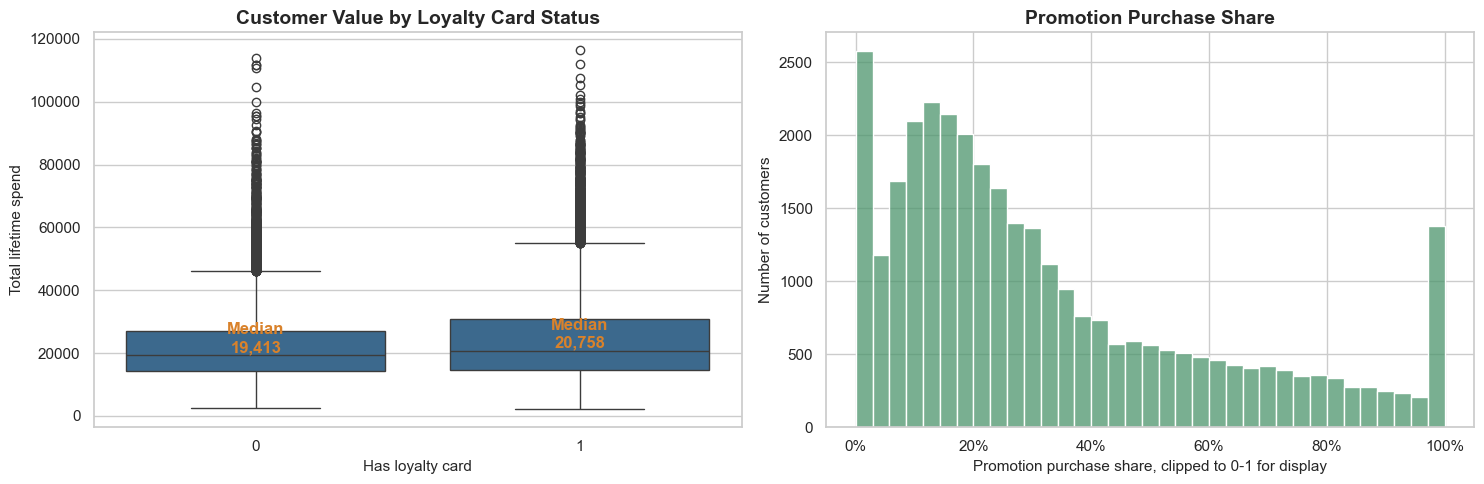

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=customer_features, x="has_loyalty_card", y="total_lifetime_spend", color=PRIMARY, ax=axes[0])
axes[0].set_title("Customer Value by Loyalty Card Status")
axes[0].set_xlabel("Has loyalty card")
axes[0].set_ylabel("Total lifetime spend")

loyalty_summary = customer_features.groupby("has_loyalty_card")["total_lifetime_spend"].median()
for index, value in loyalty_summary.items():
    axes[0].text(index, value, f"Median\n{value:,.0f}", ha="center", va="bottom", color=ACCENT, fontweight="bold")

promotion_for_plot = customer_features["percentage_of_products_bought_promotion"].clip(lower=0, upper=1)
sns.histplot(promotion_for_plot, bins=35, color=SECONDARY, ax=axes[1])
axes[1].set_title("Promotion Purchase Share")
axes[1].set_xlabel("Promotion purchase share, clipped to 0-1 for display")
axes[1].set_ylabel("Number of customers")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

save_figure("loyalty_promotion_summary.png")

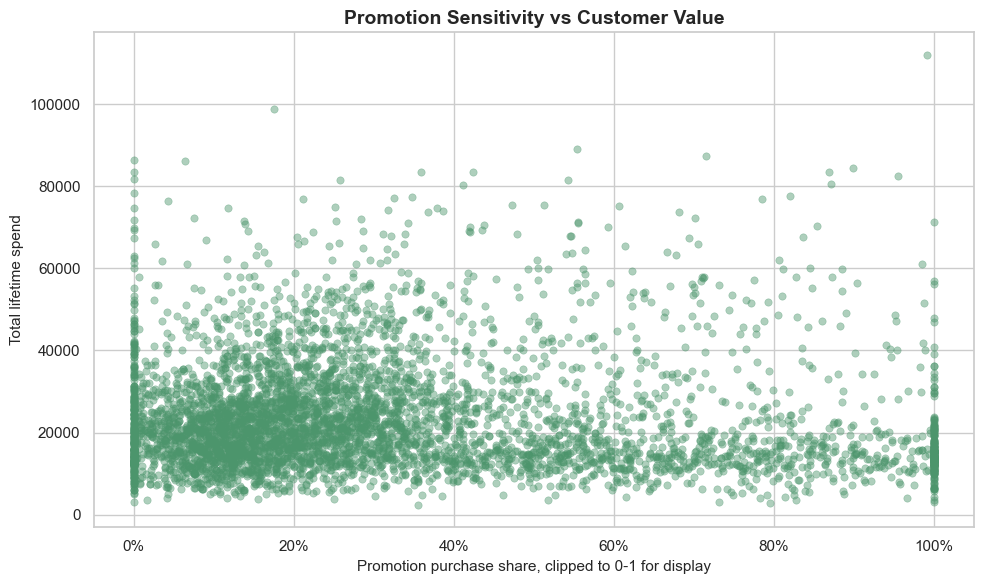

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample.assign(
        promotion_share_for_plot=plot_sample["percentage_of_products_bought_promotion"].clip(lower=0, upper=1)
    ),
    x="promotion_share_for_plot",
    y="total_lifetime_spend",
    alpha=0.45,
    s=28,
    color=SECONDARY,
    edgecolor=None,
    ax=ax,
)
ax.set_title("Promotion Sensitivity vs Customer Value")
ax.set_xlabel("Promotion purchase share, clipped to 0-1 for display")
ax.set_ylabel("Total lifetime spend")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

Loyalty-card status and promotion purchase share are both easy to explain to business stakeholders. Promotion share may separate promotion-sensitive customers, while loyalty status can help profile whether high-value customers are already engaged.

## Spending Preferences

Compare category-level spending mix. Category shares are especially useful because they describe preference rather than only customer size.

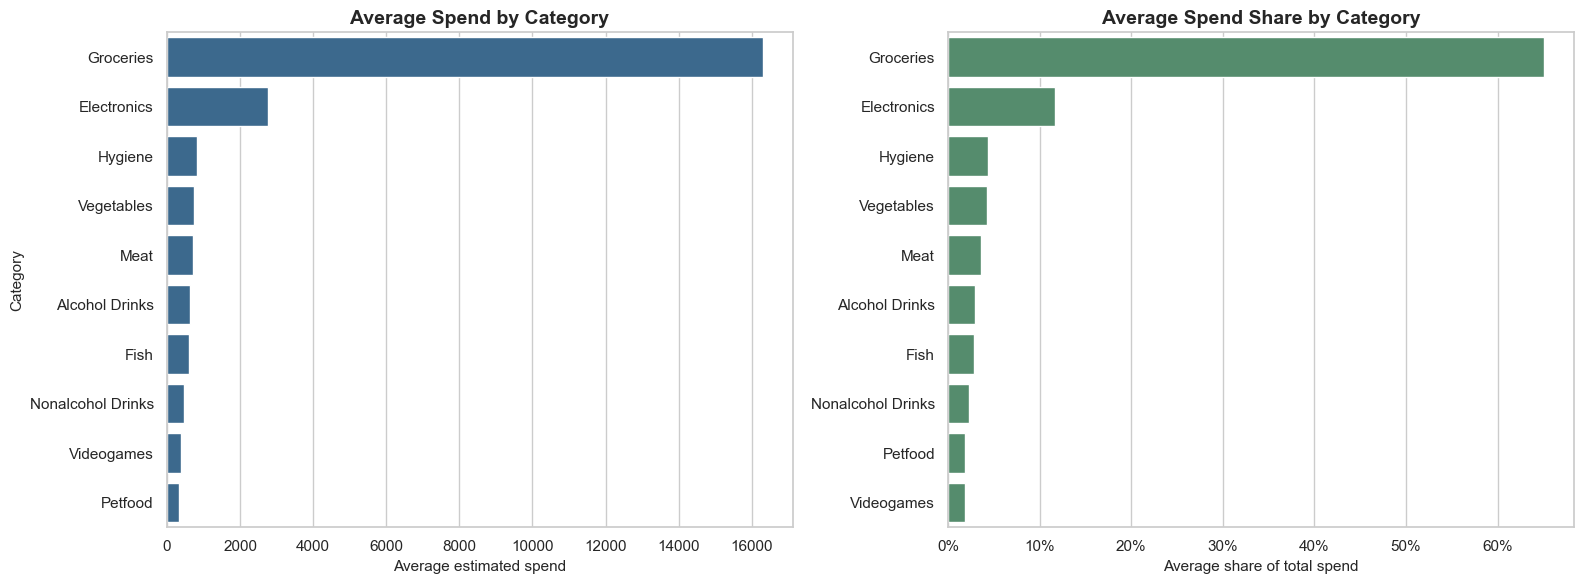

In [30]:
share_columns = [column for column in customer_features.columns if column.startswith("share_")]
category_labels = [clean_label(column) for column in share_columns]
category_name_map = dict(zip(share_columns, category_labels))

avg_spend_by_category = (
    customer_features[share_columns]
    .multiply(customer_features["total_lifetime_spend"], axis=0)
    .mean()
    .rename(index=category_name_map)
    .sort_values(ascending=False)
)

avg_share_by_category = (
    customer_features[share_columns]
    .mean()
    .rename(index=category_name_map)
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=avg_spend_by_category.values, y=avg_spend_by_category.index, color=PRIMARY, ax=axes[0])
axes[0].set_title("Average Spend by Category")
axes[0].set_xlabel("Average estimated spend")
axes[0].set_ylabel("Category")

sns.barplot(x=avg_share_by_category.values, y=avg_share_by_category.index, color=SECONDARY, ax=axes[1])
axes[1].set_title("Average Spend Share by Category")
axes[1].set_xlabel("Average share of total spend")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

save_figure("spending_preferences.png")

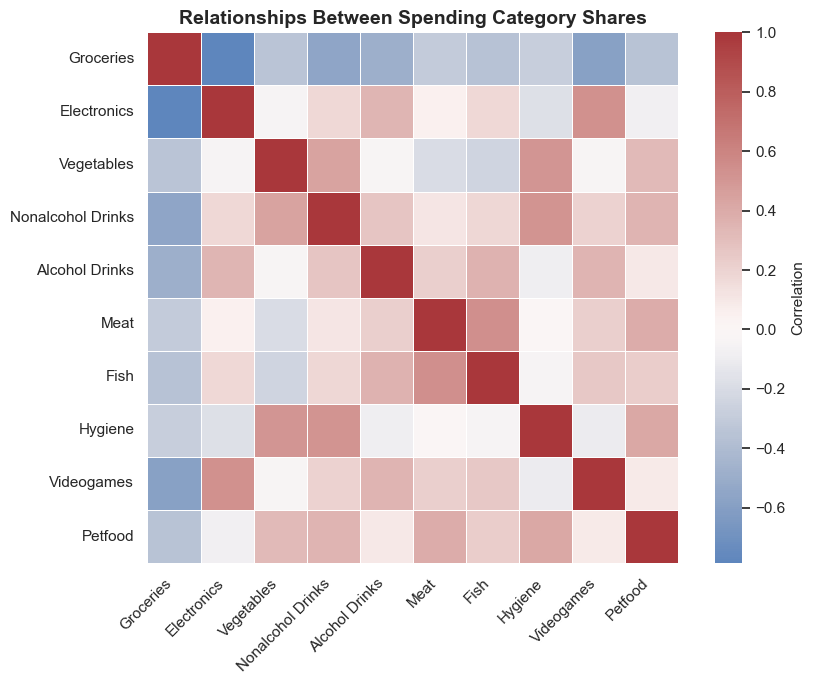

In [31]:
fig, ax = plt.subplots(figsize=(9, 7))
share_corr = customer_features[share_columns].corr()
share_corr.index = category_labels
share_corr.columns = category_labels
sns.heatmap(
    share_corr,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Relationships Between Spending Category Shares")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

save_figure("spending_share_relationships.png")

Spending shares provide preference signals that are not the same as total customer value. They are strong candidates for the first baseline because they can help define profiles such as grocery-heavy, electronics-heavy, or entertainment-oriented customers.

## Basket Behaviour

Basket features add transaction-level behaviour to the customer-level view. They are useful for EDA and later profiling, but not selected for the first K-Means input because basket coverage is incomplete.

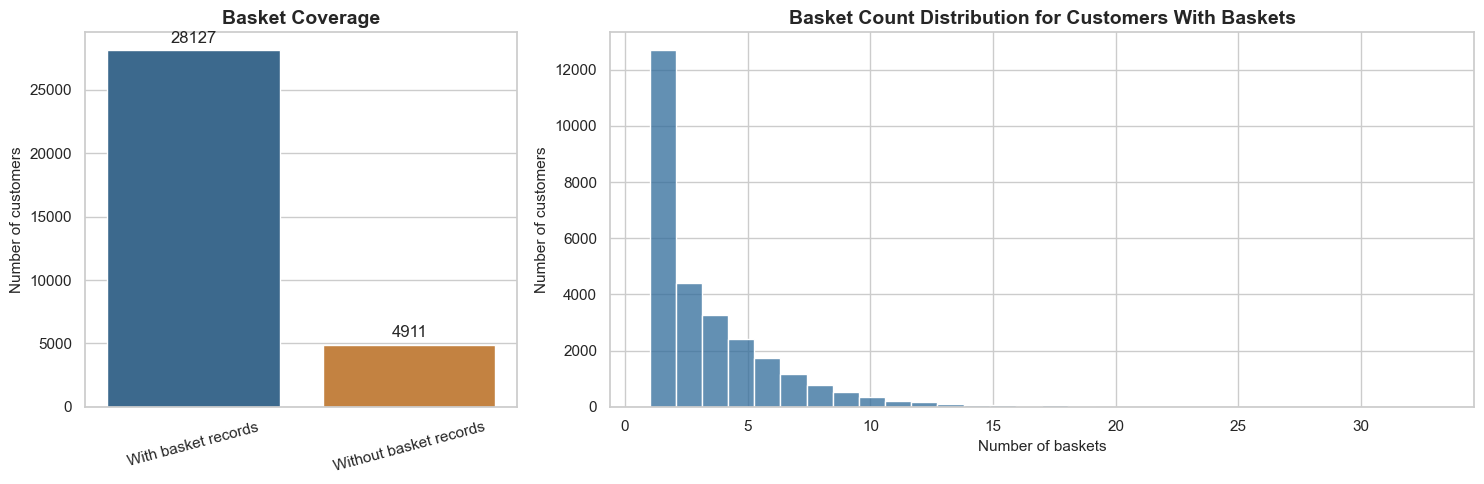

In [32]:
customers_without_baskets = int((customer_features["basket_count"] == 0).sum())
customers_with_baskets = len(customer_features) - customers_without_baskets
basket_coverage = pd.DataFrame(
    {
        "Basket record status": ["With basket records", "Without basket records"],
        "Customers": [customers_with_baskets, customers_without_baskets],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2]})
sns.barplot(data=basket_coverage, x="Basket record status", y="Customers", hue="Basket record status", palette=[PRIMARY, ACCENT], legend=False, ax=axes[0])
axes[0].set_title("Basket Coverage")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of customers")
axes[0].tick_params(axis="x", rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3)

sns.histplot(customer_features.loc[customer_features["basket_count"] > 0, "basket_count"], bins=30, color=PRIMARY, ax=axes[1])
axes[1].set_title("Basket Count Distribution for Customers With Baskets")
axes[1].set_xlabel("Number of baskets")
axes[1].set_ylabel("Number of customers")

save_figure("basket_coverage_and_frequency.png")

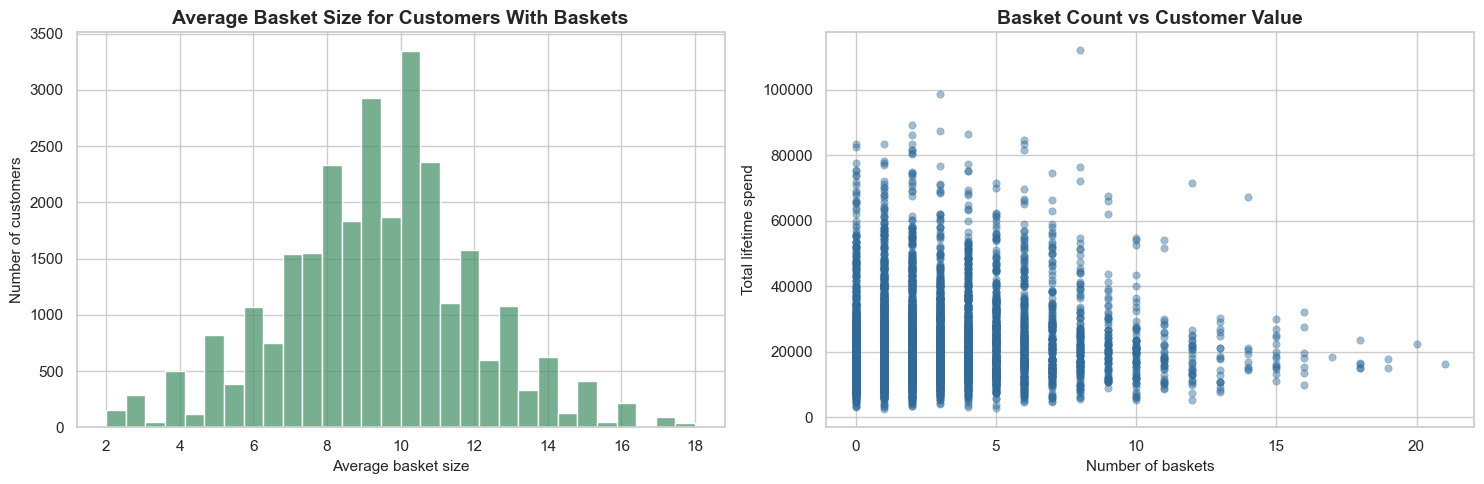

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(customer_features.loc[customer_features["avg_basket_size"] > 0, "avg_basket_size"], bins=30, color=SECONDARY, ax=axes[0])
axes[0].set_title("Average Basket Size for Customers With Baskets")
axes[0].set_xlabel("Average basket size")
axes[0].set_ylabel("Number of customers")

sns.scatterplot(
    data=plot_sample,
    x="basket_count",
    y="total_lifetime_spend",
    alpha=0.45,
    s=28,
    color=PRIMARY,
    edgecolor=None,
    ax=axes[1],
)
axes[1].set_title("Basket Count vs Customer Value")
axes[1].set_xlabel("Number of baskets")
axes[1].set_ylabel("Total lifetime spend")

plt.tight_layout()
plt.show()

The basket visuals show why these features are useful but risky: customers with no basket records form a meaningful coverage group. Basket features should be used for profiling and promotions after clusters are created, not for the first baseline clustering input.

## Correlation Overview

Review selected numerical candidates to avoid carrying too many highly related features into the first baseline.

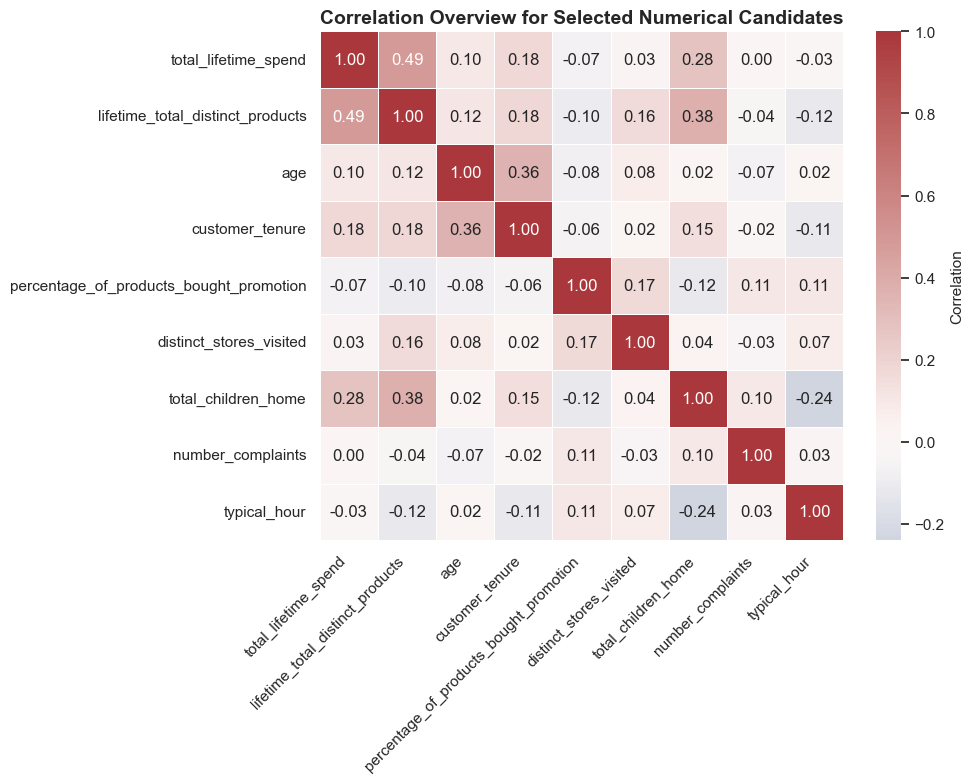

In [34]:
correlation_columns = [
    "total_lifetime_spend",
    "lifetime_total_distinct_products",
    "age",
    "customer_tenure",
    "percentage_of_products_bought_promotion",
    "distinct_stores_visited",
    "total_children_home",
    "number_complaints",
    "typical_hour",
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    customer_features[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Overview for Selected Numerical Candidates")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

save_figure("correlation_overview.png")

The selected numerical fields cover value, lifecycle, promotion behaviour, store activity, household context, complaints, and purchase timing. Raw transaction year and separate child-count fields remain excluded because more interpretable or less redundant alternatives are available.

# Feature Selection for First Clustering Baseline

Start from `customer_features_model.csv`, then keep a compact, interpretable set of scaled and encoded features for the first clustering baseline. Basket-derived features are intentionally excluded from the first selected modelling feature set because `customer_basket` does not cover every customer.

In [35]:
basket_derived_features = [
    "basket_count",
    "avg_basket_size",
    "max_basket_size",
    "min_basket_size",
    "total_items_bought_in_baskets",
    "distinct_products_in_baskets",
    "avg_distinct_products_per_basket",
]

selected_feature_columns = [
    "customer_id",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "typical_hour",
    "age",
    "customer_tenure",
    "has_loyalty_card",
    "total_children_home",
    "total_lifetime_spend",
    "share_groceries",
    "share_electronics",
    "share_vegetables",
    "share_nonalcohol_drinks",
    "share_alcohol_drinks",
    "share_meat",
    "share_fish",
    "share_hygiene",
    "share_videogames",
    "share_petfood",
    "customer_gender_female",
    "degree_level_Bsc",
    "degree_level_Msc",
    "degree_level_Phd",
    "degree_level_Unknown",
]

selected_model_features = customer_features_model[selected_feature_columns].copy()
removed_feature_columns = [
    column for column in customer_features_model.columns
    if column not in selected_feature_columns
]

basket_features_in_selected = [
    column for column in basket_derived_features
    if column in selected_model_features.columns
]

print(f"Selected columns: {len(selected_feature_columns):,}")
print(f"Removed columns: {len(removed_feature_columns):,}")
print(f"Basket-derived features selected: {basket_features_in_selected}")

Selected columns: 26
Removed columns: 14
Basket-derived features selected: []


## Feature Selection Rationale

| Decision | Features | Reason |
|---|---|---|
| Keep | customer value, lifecycle, promotion, loyalty, store activity, spending shares, gender, degree level | Simple, interpretable baseline covering value, preferences, behaviour, and customer context. |
| Keep for EDA/profiling only | basket-derived features | `customer_basket` does not cover all customers. The 4,911 customers without basket records, about 14.9%, receive zero values that may mean "not observed" rather than true zero behaviour. Including these in K-Means may create clusters based on data coverage instead of customer behaviour. |
| Remove | `basket_count`, `avg_basket_size`, `max_basket_size`, `min_basket_size`, `total_items_bought_in_baskets`, `distinct_products_in_baskets`, `avg_distinct_products_per_basket` | Excluded from the first selected modelling feature set due to basket coverage risk. They remain useful for advanced EDA and later cluster profiling. |
| Remove | `kids_home`, `teens_home`, `has_children` | Duplicated by `total_children_home` for a simpler baseline. |
| Remove | `year_first_transaction` | Duplicated by the more interpretable `customer_tenure`. |
| Remove | `latitude`, `longitude` | Potentially useful later, but risky for a first distance-based baseline because location can dominate clusters. |
| Remove | `customer_gender_male` | Redundant with `customer_gender_female` in this binary gender encoding. |

In [36]:
removed_features_table = pd.DataFrame({"removed_feature": removed_feature_columns})
removed_features_table

,removed_feature
0,kids_home
1,teens_home
2,year_first_transaction
3,latitude
4,longitude
5,has_children
6,basket_count
7,avg_basket_size
8,max_basket_size
9,min_basket_size


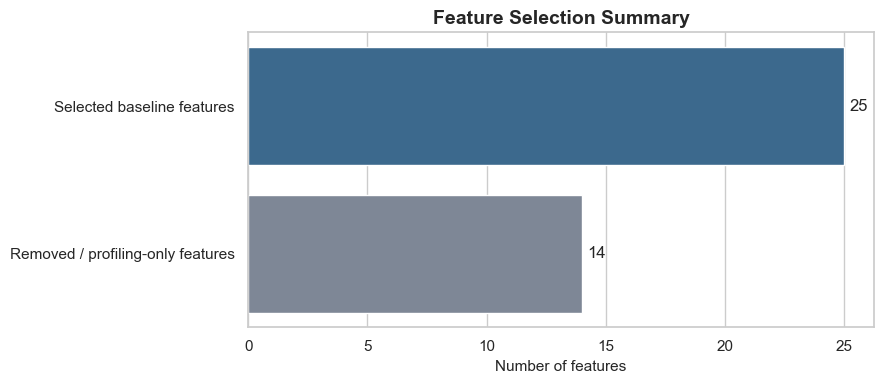

In [37]:
selection_summary = pd.DataFrame(
    {
        "Feature set": ["Selected baseline features", "Removed / profiling-only features"],
        "Count": [len(selected_feature_columns) - 1, len(removed_feature_columns)],
    }
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=selection_summary, x="Count", y="Feature set", hue="Feature set", palette=[PRIMARY, MUTED], legend=False, ax=ax)
ax.set_title("Feature Selection Summary")
ax.set_xlabel("Number of features")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4)

save_figure("feature_selection_summary.png")

## Save Selected Features

Save the first-baseline selected feature table. This still does not run clustering.

In [38]:
selected_model_features.to_csv("../data/processed/selected_model_features.csv", index=False)
print("Saved ../data/processed/selected_model_features.csv")

Saved ../data/processed/selected_model_features.csv


## Final Validation

Confirm the selected feature table is complete and keeps one row per customer.

In [39]:
validation_summary = pd.DataFrame(
    {
        "check": [
            "row count",
            "duplicated customer_id count",
            "missing values count",
            "selected feature count including customer_id",
            "removed feature count",
            "basket-derived features selected",
        ],
        "value": [
            selected_model_features.shape[0],
            selected_model_features["customer_id"].duplicated().sum(),
            selected_model_features.isna().sum().sum(),
            selected_model_features.shape[1],
            len(removed_feature_columns),
            len(basket_features_in_selected),
        ],
    }
)

validation_summary

,check,value
0,row count,33038
1,duplicated customer_id count,0
2,missing values count,0
3,selected feature count including customer_id,26
4,removed feature count,14
5,basket-derived features selected,0


In [40]:
selected_model_features.head()

,customer_id,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,typical_hour,age,customer_tenure,has_loyalty_card,total_children_home,...,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,customer_gender_female,degree_level_Bsc,degree_level_Msc,degree_level_Phd,degree_level_Unknown
0,3,0.076516,-0.099810,0.378445,1.131040,-0.134436,0.048856,-0.931644,0.810886,-0.008470,...,-1.143197,-0.691773,-0.327461,-0.186336,0.163844,1,1,0,0,0
1,4,-1.052532,-0.700126,-0.178573,-0.643434,-0.134436,-0.228627,0.459419,0.810886,-0.574949,...,-1.122408,-1.143449,1.227758,-0.073252,1.025451,1,1,0,0,0
2,5,0.076516,-0.700126,-0.641180,-0.940948,-0.342479,-0.006640,2.049206,-1.233219,-1.141429,...,1.538352,-0.434685,-0.255800,-0.492471,-0.286251,0,0,1,0,0
3,7,1.205564,-1.300442,-0.537330,-0.261363,1.113819,-0.617103,-1.130368,0.810886,-1.141429,...,0.989355,1.878166,-0.259969,3.894636,-0.425354,0,0,0,0,1
4,8,2.334612,-1.300442,-1.349253,-0.508321,0.905776,0.104353,-1.130368,0.810886,-1.141429,...,0.196543,0.483649,-0.774672,1.286198,-0.087441,0,0,0,0,1


The selected feature table is ready for a first clustering baseline. The next notebook should compare clustering options and evaluate segment quality without changing the raw data.